Enfoque: Hogar y Entorno – EDA extendido
 Variables clave
•	HOGAR_TIPO – Tipo de hogar (categórica)
•	INFO_TOTAL – Información total del hogar (numérica)
•	GHS_DUG_L1, GHS_DUG_L2 – Clasificación geoespacial (categóricas)
•	Geográficas complementarias: DEPTO, DEPTODESC, MUNIC, MUNICDESC, DISTO, DISTODESC, COD_PROP, COD_VIV


In [7]:
# 1. Cargar librerías
import pandas as pd
import numpy as np
import os

# 2. Definir rutas
base_dir = r"C:\Users\xcero\Documents\Machine Learning"
ruta_csv = os.path.join(base_dir, "datos.csv")
ruta_diccionario = os.path.join(base_dir, "Diccionario bases de datos - CPV 2024 SV.xlsx")
ruta_salida = os.path.join(base_dir, "dataset_limpio.csv")

# 3. Cargar datos
print("Cargando archivo CSV...")
df = pd.read_csv(ruta_csv, low_memory=False)

# 4. Identificar columnas tipo string
cols_string = ['DEPTO', 'DEPTODESC', 'MUNIC', 'MUNICDESC', 'DISTO', 'DISTODESC', 'COD_PROP', 'COD_VIV']
for col in cols_string:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 5. Convertir columnas restantes a numéricas
cols_numeric = [c for c in df.columns if c not in cols_string]
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 6. Limpiar valores inconsistentes
df.replace([" ", "", "NA", "N/A", "NULL", "--"], np.nan, inplace=True)

# 7. Cargar diccionario y verificar columnas
print("Cargando diccionario de variables...")
dicc = pd.read_excel(ruta_diccionario, dtype=str)
dicc.columns = dicc.columns.str.lower().str.strip()
print("Columnas encontradas en el diccionario:")
print(dicc.columns.tolist())

# 8. Renombrar columnas usando diccionario
if "mnemónico" in dicc.columns and "etiqueta" in dicc.columns:
    mapa = dict(zip(
        dicc["mnemónico"].str.strip(),
        dicc["etiqueta"].str.strip()
    ))

    print("\nColumnas originales:")
    print(df.columns.tolist())

    df.rename(columns=mapa, inplace=True)

    print("\nColumnas renombradas:")
    print(df.columns.tolist())
else:
    print("Error: El diccionario no contiene las columnas 'mnemónico' y 'etiqueta'.")

# 9. Confirmar dimensiones
print(f"\nDataset cargado con {df.shape[0]:,} filas y {df.shape[1]} columnas.")

# 10. Guardar dataset limpio
df.to_csv(ruta_salida, index=False)
print(f"\nDataset limpio guardado en: {ruta_salida}")

Cargando archivo CSV...
Cargando diccionario de variables...
Columnas encontradas en el diccionario:
[nan, 'censo de vii población y vi vivienda 2024 \ndiccionario de datos - características de las viviendas', 'unnamed: 2', 'unnamed: 3', 'unnamed: 4', 'unnamed: 5', 'unnamed: 6', 'unnamed: 7', 'unnamed: 8']
Error: El diccionario no contiene las columnas 'mnemónico' y 'etiqueta'.

Dataset cargado con 6,029,976 filas y 90 columnas.

Dataset limpio guardado en: C:\Users\xcero\Documents\Machine Learning\dataset_limpio.csv


In [8]:
import pandas as pd
import numpy as np
import os

# Ruta del archivo
ruta_csv = r"C:\Users\xcero\Documents\Machine Learning\datos.csv"

# Cargar datos
df = pd.read_csv(ruta_csv, low_memory=False)

# Mostrar columnas
print("Columnas detectadas:")
for i, col in enumerate(df.columns):
    print(f"{i+1:02d}. {col}")


Columnas detectadas:
01. DEPTO
02. DEPTODESC
03. MUNIC
04. MUNICDESC
05. DISTO
06. DISTODESC
07. COD_PROP
08. COD_VIV
09. COD_HOG
10. COD_PER
11. P02_1_PARENTESCO
12. P02_2_SEXO
13. P02_3_EDAD
14. P03_ESTADO_FAMILIAR
15. P04_RESI_MADRE
16. P04_2A_RESI_MADRE_DEPT
17. P04_2B_RESI_MADRE_MUN
18. P04_2C_RESI_MADRE_DISTRITO
19. P04_3_RESI_MADRE_OTRO_PAIS
20. P04_3B_ANIO_LLEGADA_SAL
21. P05_RESI_LUGAR
22. P05_2A_RESI_ANTERIOR_DEPT
23. P05_2B_RESI_ANTERIOR_MUN
24. P05_2C_RESI_ANTERIOR_DISTRITO
25. P05_3_RESI_ANTERIOR_OTRO_PAIS
26. P06_INDIGENA
27. P07_PUEBLO_INDIG
28. P08_AFRODESCENDIENTE
29. P09_EDUCACION_FORMAL
30. P09_1_ASISTIO_EDUCACION_FORMAL
31. P10_GRADO_APROBADO
32. P10_1_GRADO_APROBADO
33. P10_2_ANIOS_ESTUDIOS
34. P12_ANALFABETISMO
35. P12_A_PRIMER_IDIOMA
36. P12_A_1_ESPECIFIQUE_IDIOMA
37. P12_1_SEGUNDO_IDIOMA
38. P12_3_A_ENG
39. P12_3_B_ESP
40. P12_3_C_NAH
41. P12_3_D_PIS
42. P12_3_E_POT
43. P12_3_F_LESSA
44. P12_3_G_FRA
45. P12_3_H_ITA
46. P12_3_I_OTR
47. P12_4_IDIOMAS
48. P13A_DISC

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")



In [11]:
columnas_clave = [
    "hogar_tipo", "info_total", "ghs_dug_l1", "ghs_dug_l2",
    "depto", "deptodesc", "munic", "municdesc",
    "disto", "distodesc", "cod_prop", "cod_viv"
]

# Verificar existencia y tipo de cada columna
print("\nResumen de columnas clave:")
for col in columnas_clave:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(f"Tipo: {df[col].dtype}")
        print(f"Nulos: {df[col].isna().sum()} / {len(df)}")
        print(f"Valores únicos: {df[col].nunique()}")
        if df[col].dtype == "object":
            print(df[col].value_counts(dropna=False).head(10))
        else:
            print(df[col].describe())
    else:
        print(f"\n[!] Columna no encontrada: {col}")




Resumen de columnas clave:

--- hogar_tipo ---
Tipo: int64
Nulos: 0 / 6029976
Valores únicos: 7
count    6.029976e+06
mean     3.961280e+00
std      1.142256e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      7.000000e+00
Name: hogar_tipo, dtype: float64

--- info_total ---
Tipo: int64
Nulos: 0 / 6029976
Valores únicos: 2
count    6.029976e+06
mean     1.030943e+00
std      1.731622e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+00
Name: info_total, dtype: float64

--- ghs_dug_l1 ---
Tipo: int64
Nulos: 0 / 6029976
Valores únicos: 3
count    6.029976e+06
mean     2.076943e+00
std      8.021232e-01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      3.000000e+00
Name: ghs_dug_l1, dtype: float64

--- ghs_dug_l2 ---
Tipo: int64
Nulos: 0 / 6029976
Valores únicos: 7
count    6.029976e+06
mean     2.195487e+01
std      7.295093e+00
min

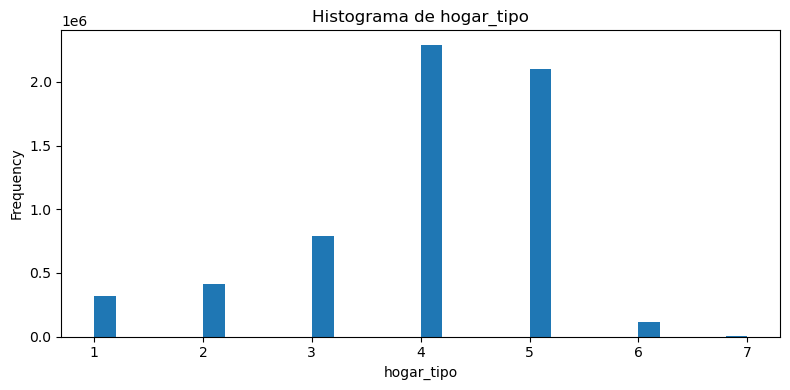

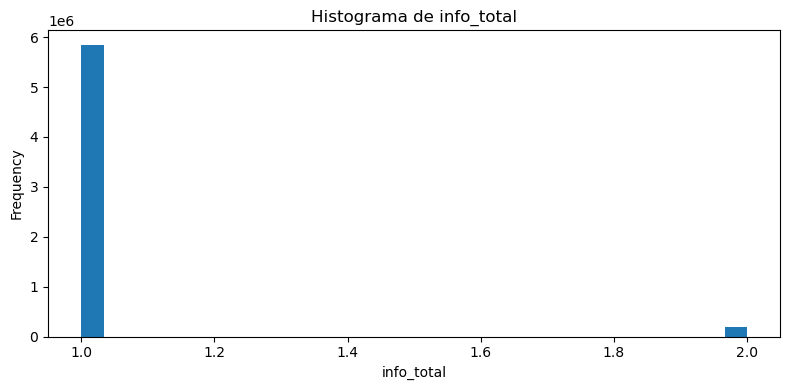

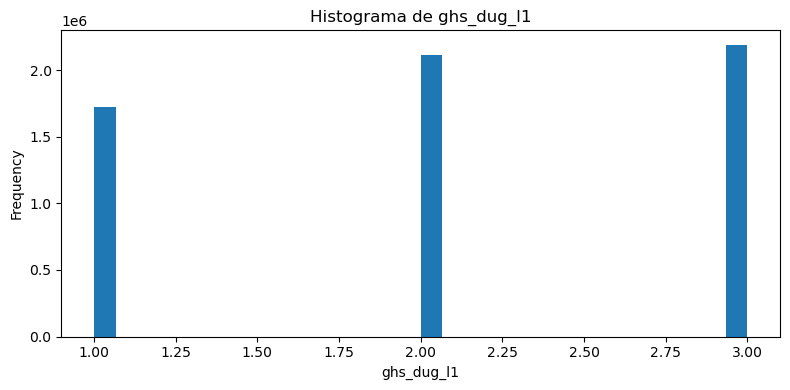

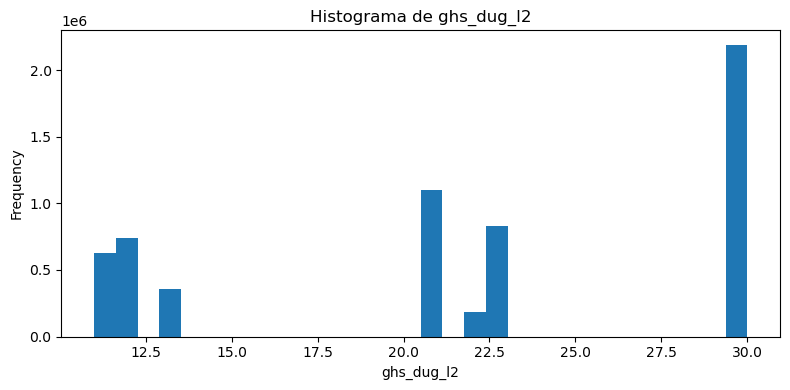

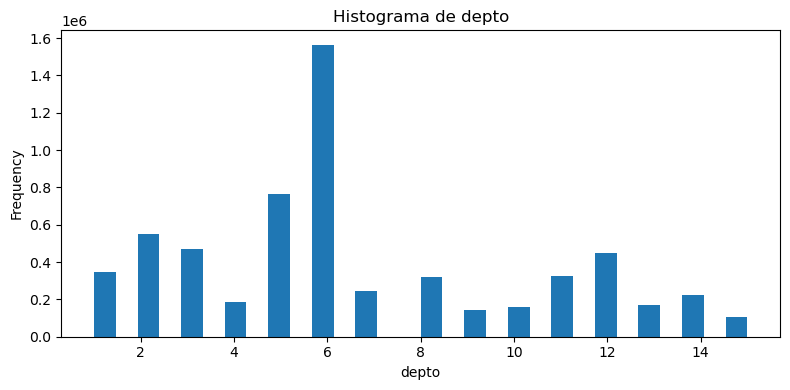

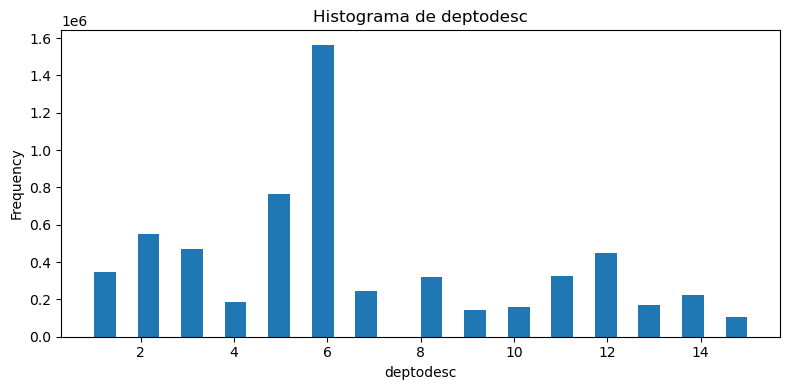

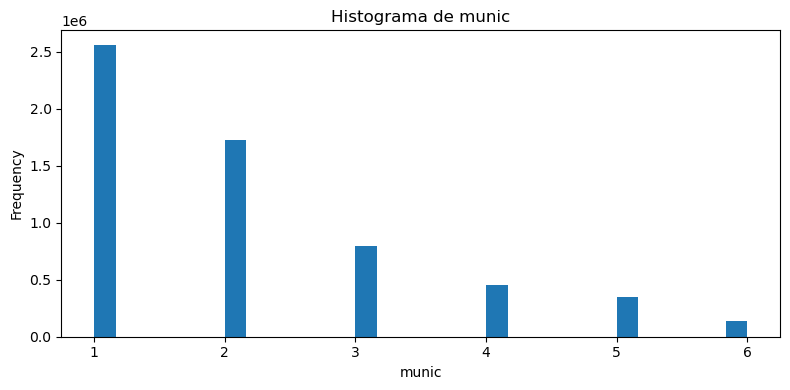

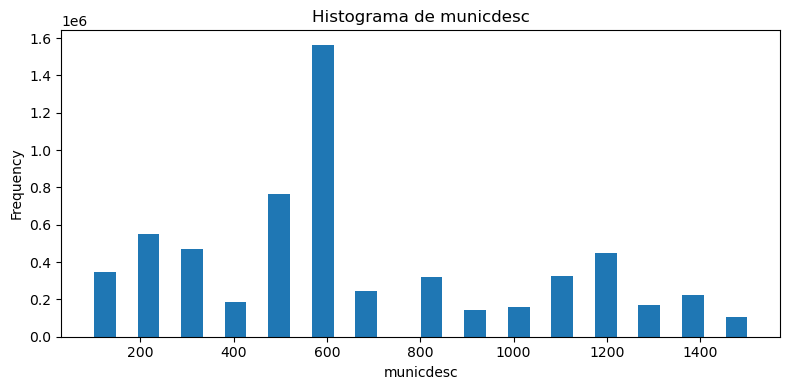

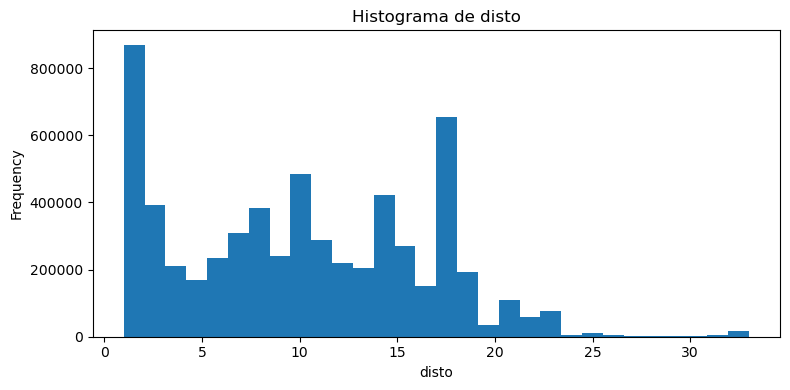

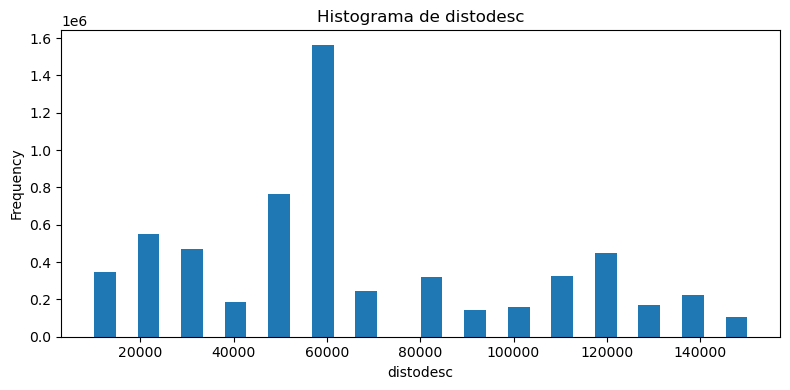

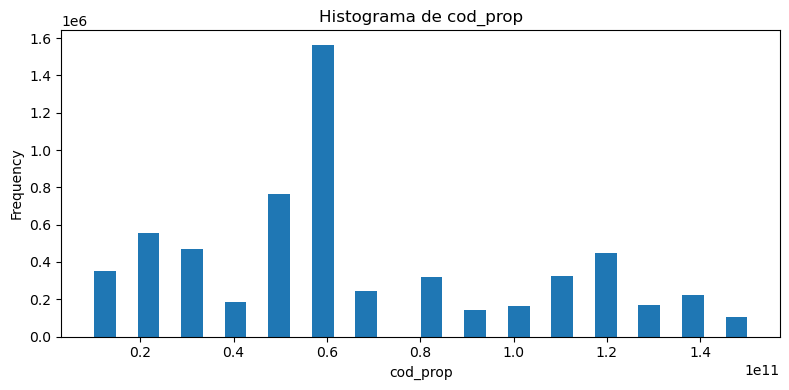

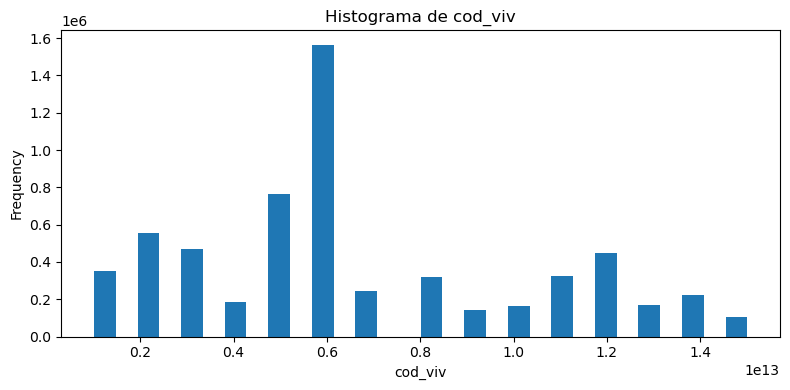

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
variables = [
    "hogar_tipo", "info_total", "ghs_dug_l1", "ghs_dug_l2",
    "depto", "deptodesc", "munic", "municdesc",
    "disto", "distodesc", "cod_prop", "cod_viv"
]

# Crear gráficas
for var in variables:
    if var in df.columns:
        plt.figure(figsize=(8, 4))
        if df[var].dtype == "object":
            df[var].value_counts(dropna=False).head(20).plot(kind="bar")
            plt.title(f"Frecuencia de {var}")
            plt.ylabel("Frecuencia")
        else:
            df[var].dropna().astype(float).plot(kind="hist", bins=30)
            plt.title(f"Histograma de {var}")
            plt.xlabel(var)
        plt.tight_layout()
        plt.show()
    else:
        print(f"[!] Columna no encontrada: {var}")
